# <a href="https://thetahat.ru/courses/ad">Введение в анализ данных</a>
## Домашнее задание 4, часть 2. Нейронные сети.


**Правила, <font color="red">прочитайте внимательно</font>:**

* Выполненную работу нужно отправить телеграм-боту `@thetahat_ds25_bot`. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайн см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**. Если вы строите интерактивные графики, их стоит прислать в формате html.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания всем участникам списывания дается штраф -2 балла к итоговой оценке за семестр.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><b>правила использования ИИ-инструментов</b></a> при решении домашнего задания.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.

**Правила оформления теоретических задач:**

* Решения необходимо оформить в виде $\LaTeX$ в markdown-ячейках. Иные способы (в т.ч. фотографии) не принимаются.
* Если вы не знаете $\LaTeX$, используйте ИИ-инструменты для оформления черновика решения. Примеры были показаны на лекции 2 по ИИ-инструментам.
* **В решениях поясняйте, чем вы пользуетесь**, хотя бы кратко.
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.


<b><font size="5" color="red">Важно!!! Правила заполнения ноутбука:</font></b>
* Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения задач.
* Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз.
* Отвечайте на вопросы, а также добавляйте новые ячейки в предложенных местах, которые обозначены `...`.
* В markdown-ячейка, содержащих описание задачи, находятся специальные отметки, которые <font color="red"><b>запрещается модифицировать</b></font>.
* При нарушении данных правил работа может получить 0 баллов.


**Баллы за задание:**

<b><font color="blue">Легкая часть</font></b> (достаточно на "хор"):

* Задача 2 &mdash; 40 баллов.

<b><font color="orange">Сложная часть</font></b> (необходимо на "отл"):

* Задача 3 &mdash; 80 баллов;
* Задача 4 &mdash; 50 баллов.

Баллы учитываются в <b>обязательной части</b> курса и не влияют на оценку по факультативной части.

In [ ]:
# Bot check

# HW_ID: fpmi_ad4_part2
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [3]:
from typing import Tuple
import numpy as np
from sklearn import datasets

from IPython.display import clear_output
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

...

sns.set(palette="Set2")
cm_bright = ListedColormap(["#FF3300", "#00CC66"])

В условии задания обозначены области, в которых запрещено использование ИИ-инструментов. Это не исчерпывающий список. Подробные правила можно найти <a href="https://thetahat.ru/courses/ai-rules">по ссылке на сайте</a>. В частности, запрещено применять ИИ-инструменты при решении теоретических частей задач, ответах на вопросы и написании выводов.

---
### <font color="blue"><i>Легкая часть</i></font>

---
### Задача 2.

**При решении задачи запрещено пользоваться ИИ-инструментами,** но можно при оформлении решения.

Рассмотрим двухслойную полносвязную нейронную сеть, которая принимает на вход $x\in\mathbb{R}^d$ и возвращает $y\in\{0, 1\}$
$$y_\theta(x) = \sigma_2 \big( \sigma_1 \left( x^{\top} W_1 + b_1 \right) W_2 + b_2 \big),$$
где
* $W_1 \in \mathbb{R}^{d \times h}, b_1 \in \mathbb{R}^{h}$ &mdash; параметры 1-го слоя,
* $W_2 \in \mathbb{R}^{h \times 1}, b_2 \in \mathbb{R}$ &mdash; параметры 2-го слоя,
* $\theta = (W_1, b_1, W_2, b_2)$ — все параметры нейросети,
* $\sigma_1(x) = \tanh x = \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}}$ &mdash; гиперболический тангенс, функция активации 1-го слоя, применяется поэлементно,
* $\sigma_2(x) = \frac{1}{1 + e^{-x}}$ &mdash; логистическая сигмоида, функция активации 2-го слоя.

**1.** Нарисуйте схематически данную нейронную сеть. Сколько у нее обучаемых параметров?

*Для вставки изображения скопируйте его и вставьте в ячейку markdown с помощью `Ctrl+V`. Должно появится либо большое количество символов (Colab), либо что-то вроде `![image.png](attachment:image.png)`.*

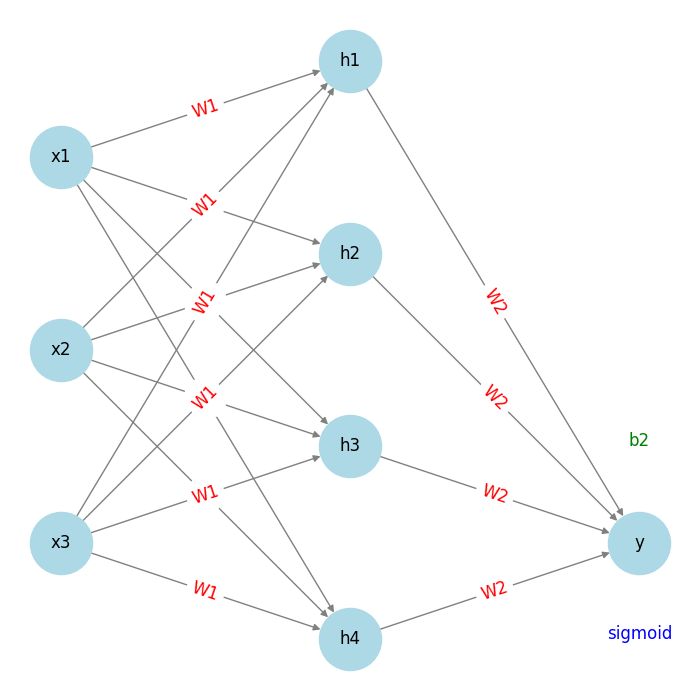

# 1. Число обучаемых параметров:

- **Матрица весов первого слоя \( W_1 \)**:  
  Имеет размерность \( d \times h \), то есть содержит \( d \cdot h \) параметров.

- **Вектор смещений первого слоя \( b_1 \)**:  
  Размерность \( h \), значит, содержит \( h \) параметров.

- **Матрица весов второго слоя \( W_2 \)**:  
  Размерность \( h \times 1 \), значит, содержит \( h \) параметров.

- **Смещение второго слоя \( b_2 \)**:  
  Скалярное значение, то есть 1 параметр.

## Общее количество параметров:
$$
d \cdot h + h + h + 1 = d \cdot h + 2h + 1
$$


**2.** Дана обучающая выборка $X \in \mathbb{R}^{n \times d}$ — матрица входных данных и $Y \in \{0, 1\}^{n}$ — таргет. Нейронная сеть обучается по этой выборке, минимизируя заданную функцию $\mathscr{L}$, в данном случае рассмотрим кросс энтропию
$$\mathscr{L}(\theta) = -\sum_{i=1}^n \big( Y_i \log y_\theta(X_i) + (1-Y_i) \log \left(1-y_\theta(X_i)\right) \big).$$

Наша цель — определить оптимальные параметры нашей модели, минимизируя функцию $\mathscr{L}(\theta)$ на заданном наборе данных. Мы будем решать эту задачу с помощью метода градиентного спуска, который требует вычисления производных по всем параметрам сети. Конечно, в данном случае несложно выписать все производные напрямую, с чем каждый из вас легко сможет справиться.

Однако прямое вычисление производных имеет квадратичную зависимость от количества параметров, что делает его неэффективным. Из-за этого мы не смогли бы быстро обучать глубокие нейронные сети. Хотя в данном случае речь идёт всего лишь о двух слоях, понимание работы методов на простых примерах было бы полезно.

На лекции был рассказан метод **обратного распространения ошибки (back propagation)** и показан его пример для двухслойной нейронной сети (на доске). Выпишите все необходимые производные для применения метода back propagation.

# Обратное распространение ошибки (Backpropagation) в двухслойной нейронной сети

## Прямой проход (Forward Pass)

1. **Вход:**
   - $x \in \mathbb{R}^d$

2. **Первый слой:**
   - $z_1 = x^T W_1 + b_1 \quad (z_1 \in \mathbb{R}^h)$
   - $a_1 = \tanh(z_1) \quad (a_1 \in \mathbb{R}^h)$

3. **Второй слой:**
   - $z_2 = a_1 W_2 + b_2 \quad (z_2 \in \mathbb{R})$
   - $a_2 = \sigma(z_2) = \frac{1}{1 + e^{-z_2}} \quad (a_2 \in \mathbb{R})$

4. **Выход:**
   - $y_{\theta}(x) = a_2$

## Функция потерь (Loss Function)

Используется кросс-энтропия:
\[
L(\theta) = - \sum_{i=1}^{n} \left( Y_i \log y_{\theta}(X_i) + (1 - Y_i) \log(1 - y_{\theta}(X_i)) \right)
\]

Для одного примера (опуская индекс $i$):
\[
L = - \left( Y \log a_2 + (1 - Y) \log(1 - a_2) \right)
\]

## Обратное распространение ошибки (Backward Pass)

### Градиенты

1. **Градиент по $z_2$:**
   \[
   \frac{\partial L}{\partial z_2} = \frac{\partial L}{\partial a_2} \cdot \frac{\partial a_2}{\partial z_2}
   \]
   - $\frac{\partial L}{\partial a_2} = a_2 - Y$
   - $\frac{\partial a_2}{\partial z_2} = a_2(1 - a_2)$
   
   Итого:
   \[
   \frac{\partial L}{\partial z_2} = (a_2 - Y)
   \]

2. **Градиенты по $W_2$ и $b_2$:**
   - $\frac{\partial L}{\partial W_2} = (a_2 - Y) \cdot a_1^T$
   - $\frac{\partial L}{\partial b_2} = a_2 - Y$

3. **Градиент по $a_1$:**
   \[
   \frac{\partial L}{\partial a_1} = \frac{\partial L}{\partial z_2} \cdot \frac{\partial z_2}{\partial a_1} = (a_2 - Y) \cdot W_2^T
   \]

4. **Градиент по $z_1$:**
   \frac{\partial L}{\partial z_1} = \frac{\partial L}{\partial a_1} \cdot \frac{\partial a_1}{\partial z_1}
   \]
   - $\frac{\partial a_1}{\partial z_1} = 1 - a_1^2$ (поэлементно)

   Итого:
   \[
   \frac{\partial L}{\partial z_1} = \left( (a_2 - Y) W_2^T \right) \odot (1 - a_1^2)
   \]
   где $\odot$ — поэлементное умножение.

5. **Градиенты по $W_1$ и $b_1$:**
   - $\frac{\partial L}{\partial W_1} = x^T \cdot \left( \frac{\partial L}{\partial z_1} \right)$
   - $\frac{\partial L}{\partial b_1} = \frac{\partial L}{\partial z_1}$

## Итоговые производные для Backpropagation

Для одного примера $(x, Y)$:
$$\frac{\partial L}{\partial W_2} = (a_2 - Y) \cdot a_1^T \\
\frac{\partial L}{\partial b_2} = a_2 - Y\\
\frac{\partial L}{\partial W_1} = x^T \cdot \left( (a_2 - Y) W_2^T \odot (1 - a_1^2) \right)\\
\frac{\partial L}{\partial b_1} = (a_2 - Y) W_2^T \odot (1 - a_1^2)$$


**3.** Выпишите итоговый алгоритм обратного распространения ошибки для данной нейросети. Нужно записать все необходимые вычисления, включая все итоговые формулы производных. Подробно поясните, почему он имеет линейную сложность.

### Итоговый алгоритм обратного распространения ошибки для двухслойной нейронной сети

Для данной нейронной сети, как описано в условиях задачи, мы вычислили необходимые производные, используя метод обратного распространения ошибки. Теперь, давайте сформулируем итоговый алгоритм и объясним его линейную сложность.

#### Шаги алгоритма обратного распространения ошибки:

**1. Прямой проход (Forward pass):**

- **Вход:** $x \in \mathbb{R}^d$

- **Первый слой:**
  - $z_1 = x^T W_1 + b_1 \quad (z_1 \in \mathbb{R}^h)$
  - $a_1 = \tanh(z_1) \quad (a_1 \in \mathbb{R}^h)$

- **Второй слой:**
  - $z_2 = a_1^T W_2 + b_2 \quad (z_2 \in \mathbb{R})$
  - $a_2 = \sigma_2(z_2) = \frac{1}{1 + e^{-z_2}} \quad (a_2 \in \mathbb{R})$

- **Выход:**
  - $y_{\theta}(x) = a_2$

**2. Функция потерь:** Используем кросс-энтропию:
$$
L = - \left( Y \log a_2 + (1 - Y) \log(1 - a_2) \right)
$$

---

**3. Обратный проход (Backward pass):**

- **Градиент по $z_2$:**
$$
\frac{\partial L}{\partial z_2} = (a_2 - Y) \cdot a_2 (1 - a_2)
$$

- **Градиенты по $W_2$ и $b_2$:**
  - $\frac{\partial L}{\partial W_2} = (a_2 - Y) \cdot a_2 (1 - a_2) \cdot a_1^T$
  - $\frac{\partial L}{\partial b_2} = (a_2 - Y) \cdot a_2 (1 - a_2)$

- **Градиент по $a_1$:**
$$
\frac{\partial L}{\partial a_1} = (a_2 - Y) \cdot a_2 (1 - a_2) \cdot W_2^T
$$

- **Градиент по $z_1$:**
$$
\frac{\partial L}{\partial z_1} = \left( (a_2 - Y) \cdot a_2 (1 - a_2) \cdot W_2^T \right) \odot (1 - a_1^2)
$$
где $\odot$ — поэлементное умножение.

- **Градиенты по $W_1$ и $b_1$:**
  - $\frac{\partial L}{\partial W_1} = x^T \cdot \left( (a_2 - Y) \cdot a_2 (1 - a_2) \cdot W_2^T \odot (1 - a_1^2) \right)$
  - $\frac{\partial L}{\partial b_1} = \left( (a_2 - Y) \cdot a_2 (1 - a_2) \cdot W_2^T \right) \odot (1 - a_1^2)$

**4. Обновление параметров:**

Параметры сети обновляются с использованием градиентного спуска:

- $W_1 \leftarrow W_1 - \eta \frac{\partial L}{\partial W_1}$
- $b_1 \leftarrow b_1 - \eta \frac{\partial L}{\partial b_1}$
- $W_2 \leftarrow W_2 - \eta \frac{\partial L}{\partial W_2}$
- $b_2 \leftarrow b_2 - \eta \frac{\partial L}{\partial b_2}$

---

### Линейная сложность алгоритма

Теперь давайте рассмотрим, почему этот алгоритм имеет линейную сложность.

**1. Прямой проход (Forward pass):**

Для вычисления $z_1$, $a_1$, $z_2$ и $a_2$ нужно выполнить несколько операций матричных умножений и применить функции активации. Основные операции — это умножение матрицы размером $d \times h$ с вектором размерности $d$, и умножение вектора размерности $h$ на матрицу $h \times 1$. Все эти операции имеют сложность $O(d \cdot h)$.

Функции активации $\tanh(z_1)$ и $\sigma_2(z_2)$ также применяются поэлементно, что имеет сложность $O(h)$ и $O(1)$ соответственно. Поэтому сложность прямого прохода составляет $O(d \cdot h)$.

**2. Обратный проход (Backward pass):**

Для вычисления градиентов также нужно выполнить несколько операций матричных умножений и поэлементных операций (например, поэлементное умножение $\odot$). На каждом шаге нужно вычислить градиенты для $W_2$, $b_2$, $W_1$, и $b_1$, что включает в себя умножения, которые имеют сложность $O(d \cdot h)$.

Таким образом, сложность обратного распространения ошибки также $O(d \cdot h)$, так как операции, связанные с вычислением градиентов для каждого слоя, также имеют линейную зависимость от количества параметров.

**3. Обновление параметров:**

Обновление параметров происходит за время $O(d \cdot h)$, так как требуется один проход по всем параметрам для их обновления.

Таким образом, общая сложность алгоритма для каждого примера (учитывая как прямой, так и обратный проход, а также обновление параметров) составляет $O(d \cdot h)$, где:

- $d$ — размерность входных данных,
- $h$ — количество нейронов в скрытом слое.

### Почему сложность линейная

Каждый проход через сеть (как прямой, так и обратный) требует выполнения операций, которые пропорциональны количеству параметров сети (и входных данных), что делает сложность линейной относительно числа параметров.

В этой задаче количество параметров в сети — это $d \cdot h + h + h + 1 = d \cdot h + 2h + 1$ для параметров $W_1$, $b_1$, $W_2$, $b_2$. Таким образом, сложность вычислений линейно зависит от размера сети, что является основной причиной линейной сложности алгоритма.

Таким образом, алгоритм обратного распространения ошибки имеет линейную сложность $O(d \cdot h)$, что делает его эффективным для задач с умеренным количеством параметров.


**Выводы:**

### Выводы

1. **Алгоритм обратного распространения ошибки:**  
   Мы рассмотрели двухслойную полносвязную нейронную сеть и разработали алгоритм обратного распространения ошибки. Он включает прямой проход для вычисления выходных значений и обратный проход для вычисления градиентов, которые затем используются для обновления параметров модели с помощью градиентного спуска.

2. **Процесс обучения:**  
   В процессе обучения нейронной сети происходит оптимизация параметров сети ($W_1$, $b_1$, $W_2$, $b_2$) для минимизации функции потерь. Мы использовали кросс-энтропию в качестве функции потерь, что является стандартным выбором для задач классификации с бинарным выходом.

3. **Линейная сложность:**  
   Сложность алгоритма обратного распространения ошибки является линейной относительно количества параметров в сети, что делает его достаточно эффективным для умеренных размеров нейросетей. В данном случае сложность вычислений для каждого примера составляет $O(d \cdot h)$, где $d$ — размерность входных данных, а $h$ — количество нейронов в скрытом слое.

4. **Количество параметров:**  
   Число обучаемых параметров сети в данной задаче составляют $d \cdot h + 2h + 1$. Это значение определяет сложность алгоритма, которая пропорциональна количеству параметров и входных данных. Таким образом, для эффективного обучения даже небольших нейросетей можно использовать стандартный метод градиентного спуска с обратным распространением ошибки.



...

**Внимание!** Решение, которое будет иметь сверхлинейную сложность, не будет оценено совсем. Считать производные вы все умеете, задача — вычислять их эффективно алгоритмически.

---
### <font color="orange"><i>Сложная часть</i></font>

---
### Задача 3.

**1.** На практике, чтобы сделать численные вычисления градиентов более стабильными, в качестве функции ошибки используют композицию бинарной кроссэнтропии и сигмоиды, передавая ей логиты в качестве аргументов, то есть выходы последнего линейного слоя. Выведите итоговую формулу градиента бинарной кроссэнтропии по выходу сети до применения сигмоиды.

Для вывода формулы градиента бинарной кросс-энтропии по выходу сети до применения сигмоиды, рассмотрим следующие шаги.

1. **Бинарная кросс-энтропия**:  
   Кросс-энтропийная ошибка для бинарной классификации для одного примера выглядит следующим образом:
   $$
   L(y, \hat{y}) = - \left[ y \log(\hat{y}) + (1 - y) \log(1 - \hat{y}) \right]
   $$
   где:
   - $y$ — истинный класс (0 или 1),
   - $\hat{y}$ — предсказанное значение вероятности (выход функции сигмоиды).

2. **Сигмоида**:  
   Функция сигмоиды, которая преобразует логиты $z$ в вероятности $\hat{y}$, выглядит так:
   $$
   \hat{y} = \sigma(z) = \frac{1}{1 + \exp(-z)}
   $$
   где $z$ — это линейный выход последнего слоя сети.

3. **Градиент по выходу сети до применения сигмоиды**:  
   Для вычисления градиента бинарной кросс-энтропии по логитам $z$, мы применяем цепное правило. Сначала вычислим градиент кросс-энтропийной функции по $\hat{y}$:
   $$
   \frac{\partial L}{\partial \hat{y}} = - \left( \frac{y}{\hat{y}} - \frac{1 - y}{1 - \hat{y}} \right)
   $$

   Теперь, для вычисления градиента по $z$, применим цепное правило. Градиент функции сигмоиды по $z$:
   $$
   \frac{\partial \hat{y}}{\partial z} = \hat{y} (1 - \hat{y})
   $$

   Таким образом, общий градиент будет:
   $$
   \frac{\partial L}{\partial z} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z}
   $$

   Подставляем выражения для градиентов:
   $$
   \frac{\partial L}{\partial z} = \left( - \left( \frac{y}{\hat{y}} - \frac{1 - y}{1 - \hat{y}} \right) \right) \cdot \hat{y} (1 - \hat{y})
   $$

   Упрощая, получаем итоговую формулу для градиента:
   $$
   \frac{\partial L}{\partial z} = \hat{y} - y
   $$

Таким образом, градиент бинарной кросс-энтропии по логитам (выходам сети до применения сигмоиды) равен разнице между предсказанным значением вероятности и истинным значением $y$.


**2.** Реализуйте класс обучения нейронной сети из задачи 2 в sklearn-стиле, используя только библиотеку `numpy`. Используйте представленный ниже шаблон.

**Особенности:**
* Функция `_backward` должна реализовывать метод back propagation полностью на основе формул из задачи 2. Функция должна *накапливать* градиенты, подробнее см. <a href="https://thetahat.ru/courses/ad/main/4/nn_simple_examples">ноутбук с занятия по нейросетям</a>.
* При реализации функции `_backward` необходимо сразу посчитать производную функции ошибку по выходу сети до применения функции активации, что в коде реализуется функцией `output_gradient`. Это необходимо для повышения стабильности численных вычислений, что также используется в PyTorch.
* Желательно, чтобы градиент не зависел от размера входных данных, поэтому при вычислении градиентов по параметрам, рекомендуется разделить их на размер батча.
* При необходимости вы можете менять внутреннюю структуру методов, кроме методов `__init__`, `fit`, `predict`, `predict_proba`. В случае изменений исправляйте также документацию и типизацию аргументов, иначе оценка может быть снижена.
* **При реализации класса запрещено пользоваться ИИ-инструментами.** За исключением случаев обновления документации класса при необходимости.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

class TwoLayersNNClassifier:
    """Двухслойная нейронная сеть для задачи бинарной классификации.

    Параметры:
        input_size (int): Размер входного вектора.
        hidden_size (int): Количество нейронов в скрытом слое.
        learning_rate (float, optional): Скорость обучения (по умолчанию 0.01).
        n_epoch (int, optional): Количество эпох обучения (по умолчанию 100).
        weight_init_scale (float, optional): Масштаб для инициализации весов (по умолчанию 1).
    """

    def __init__(
        self,
        input_size: int,
        hidden_size: int,
        learning_rate: float = 0.01,
        n_epoch: int = 100,
        weight_init_scale: float = 1,
    ):
        self.learning_rate = learning_rate
        self.n_epoch = n_epoch
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.weight_init_scale = weight_init_scale

        # Инициализация весов
        self._initialize_weights()

        # Инициализация градиентов
        self._zero_grad()

        # Для хранения истории потерь
        self.loss_history = []

    def _initialize_weights(self):
        """Инициализирует веса сети случайными значениями."""
        self.W1 = self._init_weight_matrix(self.input_size, self.hidden_size)
        self.b1 = self._init_weight_matrix(1, self.hidden_size)
        self.W2 = self._init_weight_matrix(self.hidden_size, 1)
        self.b2 = self._init_weight_matrix(1, 1)

    def _init_weight_matrix(self, rows: int, cols: int) -> np.ndarray:
        """Инициализирует матрицу весов случайными значениями.

        Параметры:
            rows (int): Количество строк.
            cols (int): Количество столбцов.

        Возвращает:
            np.ndarray: Матрица весов.
        """
        return (np.random.rand(rows, cols) * 2 - 1) * self.weight_init_scale

    @staticmethod
    def tanh_derivative(x: np.ndarray) -> np.ndarray:
        """Вычисляет производную функции гиперболического тангенса.

        Параметры:
            x (np.ndarray): Входной массив.

        Возвращает:
            np.ndarray: Производная функции tanh.
        """
        return 1 - np.tanh(x)**2

    @staticmethod
    def sigmoid(x: np.ndarray, scale: int = 1000) -> np.ndarray:
        """Вычисляет логистическую сигмоиду.

        Параметры:
            x (np.ndarray): Входной массив.
            scale (int, optional): Максимальное абсолютное значение для ограничения (по умолчанию 1000).

        Возвращает:
            np.ndarray: Значения сигмоиды.
        """
        x = np.clip(x, -scale, scale)  # Ограничиваем значения
        return 1 / (1 + np.exp(-x))

    @staticmethod
    def binary_crossentropy(y_pred: np.ndarray, y_true: np.ndarray) -> float:
        """Вычисляет значение бинарной кросс-энтропии.

        Параметры:
            y_pred (np.ndarray): Предсказанные значения (вероятности).
            y_true (np.ndarray): Истинные значения (0 или 1).

        Возвращает:
            float: Значение бинарной кросс-энтропии.
        """
        # Добавление небольшого значения для предотвращения логарифма от 0
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    @staticmethod
    def output_gradient(logits: np.ndarray, y: np.ndarray) -> np.ndarray:
        """Вычисляет градиент по выходу сети до применения сигмоиды.

        Параметры:
            logits (np.ndarray): Предсказанные значения.
            y (np.ndarray): Истинные значения.

        Возвращает:
            np.ndarray: Градиент по выходу до применения сигмоиды.
        """
        # Градиент по выходу сети до применения сигмоиды
        return logits - y

    def _forward(self, X: np.ndarray) -> np.ndarray:
        """Выполняет прямой проход по сети.

        Параметры:
            X (np.ndarray): Входные данные.

        Возвращает:
            np.ndarray: Выход сети (вероятности).
        """
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = np.tanh(self.Z1)  # Скрытый слой
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.sigmoid(self.Z2)  # Выходной слой
        return self.A2

    def _backward(self, X: np.ndarray, y: np.ndarray):
        """Выполняет обратный проход (backpropagation), накапливает градиенты.

        Параметры:
            X (np.ndarray): Входные данные.
            y (np.ndarray): Истинные значения.
        """

        # Градиент по выходу до применения сигмоиды
        dZ2 = self.output_gradient(self.Z2, y)

        # Градиент по параметрам 2-го слоя
        self.dW2 = np.dot(self.A1.T, dZ2) / X.shape[0]
        self.db2 = np.sum(dZ2, axis=0, keepdims=True) / X.shape[0]

        # Градиент по выходу скрытого слоя
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * self.tanh_derivative(self.Z1)

        # Градиент по параметрам 1-го слоя
        self.dW1 = np.dot(X.T, dZ1) / X.shape[0]
        self.db1 = np.sum(dZ1, axis=0, keepdims=True) / X.shape[0]

    def _step(self):
        """Обновляет веса сети на основе вычисленных градиентов."""
        self.W1 -= self.learning_rate * self.dW1
        self.b1 -= self.learning_rate * self.db1
        self.W2 -= self.learning_rate * self.dW2
        self.b2 -= self.learning_rate * self.db2

    def _zero_grad(self):
        """Обнуляет градиенты перед следующим шагом обучения."""
        self.dW1 = np.zeros_like(self.W1)
        self.db1 = np.zeros_like(self.b1)
        self.dW2 = np.zeros_like(self.W2)
        self.db2 = np.zeros_like(self.b2)

    def _show_progress(self, epoch: int, plot_freq: int):
        """Выводит прогресс обучения на каждой итерации.

        Параметры:
            epoch (int): Номер текущей эпохи.
            plot_freq (int): Частота отрисовки графика.
        """
        info_text = f"Эпоха {epoch + 1}/{self.n_epoch}, Лосс: {self.loss_history[-1]:.4f}"

        if plot_freq == 0:
            clear_output(wait=True)  # Очистка вывода
            print(info_text)

        elif (epoch + 1) % plot_freq == 0:
            clear_output(wait=True)  # Очистка вывода
            plt.figure(figsize=(8, 4))
            plt.plot(self.loss_history)
            plt.xlabel("Номер эпохи")
            plt.ylabel("Лосс")
            plt.title(info_text)
            plt.show()

    def fit(self, X: np.ndarray, y: np.ndarray, verbose: bool = True, plot_freq: int = 0):
        """Обучает модель на предоставленных данных.

        Параметры:
            X (np.ndarray): Входные данные.
            y (np.ndarray): Истинные значения (0 или 1).
            verbose (bool, optional): Если True, выводит прогресс обучения (по умолчанию True).
            plot_freq (int, optional): Частота отрисовки графика.
                    Если 0, график не рисуется (по умолчанию 0).
        """
        y = y[:, None]
        self.loss_history = []  # Очистка истории потерь перед обучением

        for epoch in range(self.n_epoch):
            # Прямой проход по сети
            y_pred = self._forward(X)
            loss = self.binary_crossentropy(y_pred, y)
            self.loss_history.append(loss)  # Сохраняем значение потерь

            # Обратный проход и шаг градиентного спуска
            self._backward(X, y)
            self._step()

            if verbose:
                self._show_progress(epoch, plot_freq)

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Предсказывает классы для входных данных.

        Параметры:
            X (np.ndarray): Входные данные.

        Возвращает:
            np.ndarray: Предсказанные классы (0 или 1).
        """
        y_pred = self._forward(X)
        return (y_pred > 0.5).astype(int)  # Порог 0.5 для бинарной классификации

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Возвращает вероятности принадлежности к классам 0 и 1.

        Параметры:
        X (np.ndarray): Входные данные.

        Возвращает:
        np.ndarray: Матрица вероятностей формы (n, 2), где n — количество объектов.
                   Первый столбец — вероятность класса 0, второй — класса 1.
        """
        prob_class_1 = self._forward(X)  # Вероятность класса 1
        prob_class_0 = 1 - prob_class_1  # Вероятность класса 0
        return np.hstack((prob_class_0, prob_class_1))  # Объединяем в матрицу (n, 2)


**3.** Сгенерируем искусственные данные

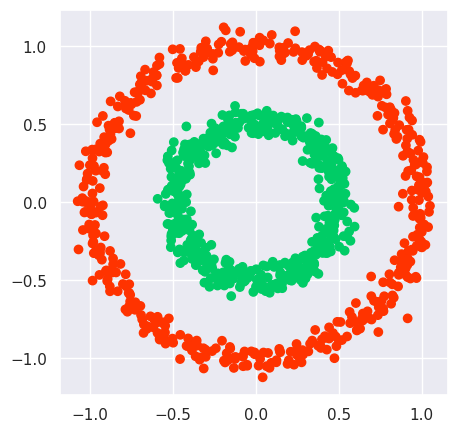

In [5]:
# Генерация данных
n_samples = 1024
X, y = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.05)

# Визуализация данных
plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cm_bright)
plt.show()

Обучите реализованную ранее нейросеть решать задачу классификации на основе этой выборки.

*Периодически во время обучения рисуйте график лосса. Если он возрастает, стоит поискать ошибку.*

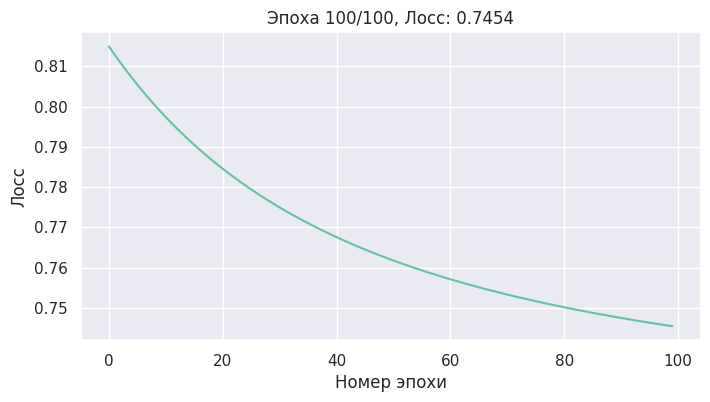

Accuracy: 50.00%


In [7]:
# Инициализация модели
model = TwoLayersNNClassifier(input_size=2, hidden_size=8, learning_rate=0.01, n_epoch=100)

# Обучение модели
model.fit(X, y, verbose=True, plot_freq=10)

# Оценка точности
y_pred_class = model.predict(X)
accuracy = np.mean(y_pred_class == y)
print(f"Accuracy: {accuracy * 100:.2f}%")

С помощью функции `np.meshgrid` создайте двухмерную сетку в диапазоне $[-1.5, 1.5]$ по каждой координате с шагом не более $0.02$. Для каждой точки сетки посчитайте оценки вероятностей принадлежности тому или иному классу.

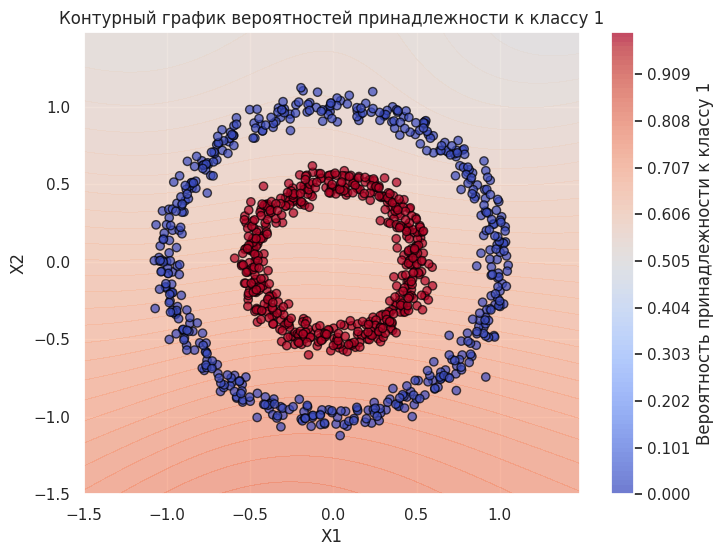

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Создание сетки с диапазоном [-1.5, 1.5] по каждой координате с шагом 0.02
x_min, x_max = -1.5, 1.5
y_min, y_max = -1.5, 1.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# Преобразуем сетку в массив точек
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Для каждой точки на сетке предсказываем вероятности принадлежности к классам
probabilities = model.predict_proba(grid_points)

# Получаем вероятности для класса 1 (второй столбец)
Z = probabilities[:, 1].reshape(xx.shape)

# Визуализация контурного графика для вероятности принадлежности к классу 1
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, levels=np.linspace(0, 1, 100), cmap='coolwarm', alpha=0.7)
plt.colorbar(label="Вероятность принадлежности к классу 1")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k', marker='o', alpha=0.7)
plt.title("Контурный график вероятностей принадлежности к классу 1")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()


Визуализируйте полученные предсказания классов и вероятностей.

*Если у вас получилось плохое качество, попробуйте увеличить количество нейронов. Если не помогает, возможно, где-то ошибка.*

In [ ]:
...

Немного увеличим разброс данных

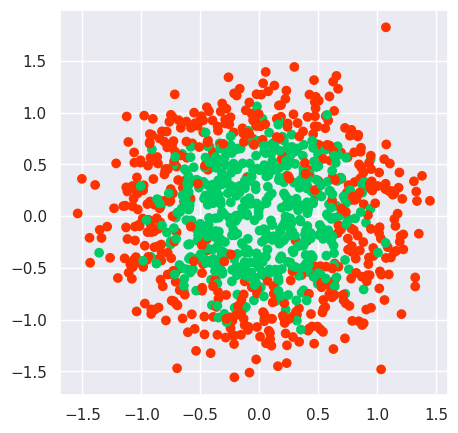

In [13]:
# Генерация данных
n_samples = 1024
X, y = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.25)

# Визуализация данных
plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cm_bright)
plt.show()

Повторите те же действия с новыми данными.

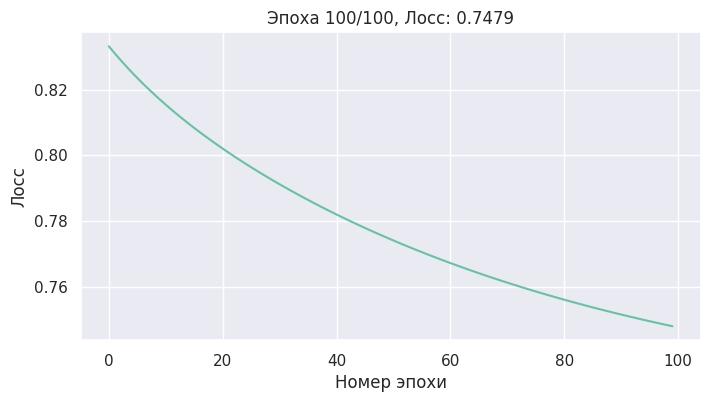

Accuracy: 50.00%


In [14]:
# Инициализация модели
model = TwoLayersNNClassifier(input_size=2, hidden_size=8, learning_rate=0.01, n_epoch=100)

# Обучение модели
model.fit(X, y, verbose=True, plot_freq=10)

# Оценка точности
y_pred_class = model.predict(X)
accuracy = np.mean(y_pred_class == y)
print(f"Accuracy: {accuracy * 100:.2f}%")

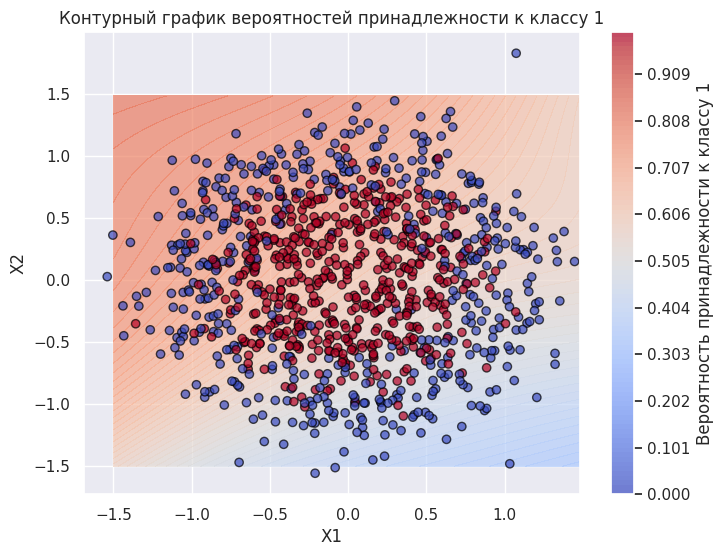

In [15]:
# Создание сетки с диапазоном [-1.5, 1.5] по каждой координате с шагом 0.02
x_min, x_max = -1.5, 1.5
y_min, y_max = -1.5, 1.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# Преобразуем сетку в массив точек
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Для каждой точки на сетке предсказываем вероятности принадлежности к классам
probabilities = model.predict_proba(grid_points)

# Получаем вероятности для класса 1 (второй столбец)
Z = probabilities[:, 1].reshape(xx.shape)

# Визуализация контурного графика для вероятности принадлежности к классу 1
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, levels=np.linspace(0, 1, 100), cmap='coolwarm', alpha=0.7)
plt.colorbar(label="Вероятность принадлежности к классу 1")
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k', marker='o', alpha=0.7)
plt.title("Контурный график вероятностей принадлежности к классу 1")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

**Выводы:**

## Выводы по результатам работы нейросети

### 1. Шум в данных влияет на классификацию

- **Первая картинка** (с шумом 0.05) показывает чётко выраженные кольцевые кластеры. Нейросеть хорошо различает классы, и граница между ними уверенная.
- **Вторая картинка** (с шумом 0.25) демонстрирует более хаотичное распределение точек. Модель испытывает сложности с корректным разделением классов, так как переход между красными и синими точками менее чёткий.

### 2. Модель способна выделять нелинейные границы

- На обоих изображениях видно, что модель обучилась выявлять сложные (нелинейные) границы между классами.
- При высоком уровне шума (вторая картинка) границы становятся менее точными, что говорит о **чувствительности модели к шуму**.

### 3. Возможные улучшения модели

- **Увеличение количества нейронов в скрытом слое** может помочь лучше улавливать сложные закономерности, особенно при высоком шуме.
- **Добавление L2-регуляризации** может уменьшить влияние выбросов и шумовых точек.
- **Использование других архитектур** (например, сверточных нейросетей или более глубоких MLP) также может повысить качество классификации.

### Итог
Модель работает хорошо, но её эффективность зависит от уровня шума в данных. Чем меньше шум, тем более чётко выражены границы между классами.



**4.** Теперь давайте применим нашу нейронную сеть к данным MNIST.

Загрузите данные. Для этого воспользуйтесь кодом из задачи 1. Обратите внимание, что поскольку наша сеть реализована на `numpy` и принимает `numpy`-матрицы, потребуется предварительно перевести `torch`-тензоры в `numpy`-массивы.

Поскольку наша сеть была разработана для бинарной классификации, мы будем рассматривать изображения, на которых представлены только две цифры: `0` и `1`. Возьмите по 1000 изображений каждого символа и преобразуйте их в векторы. Также выделите изображения из тестовой выборки, соответствующие этим цифрам.

100%|██████████| 9.91M/9.91M [00:00<00:00, 53.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.73MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 13.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.91MB/s]


Размер обучающих данных: (2000, 784)
Размер тестовых данных: (2115, 784)


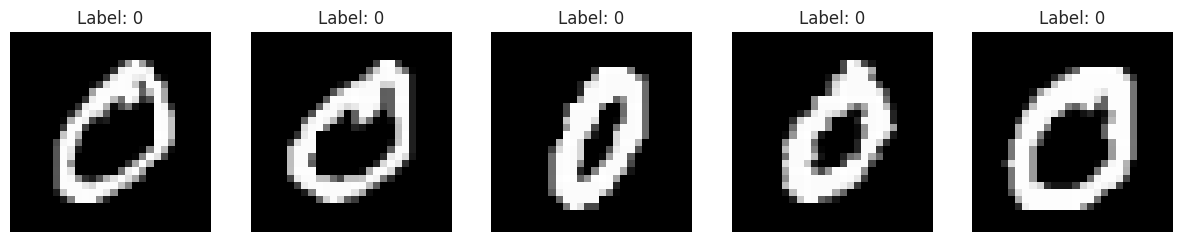

In [17]:
import numpy as np
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# Шаг 1: Загрузка данных MNIST с использованием torchvision
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])  # Преобразуем изображения в одномерные векторы

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Шаг 2: Отбор только изображений с цифрами 0 и 1
train_data = []
test_data = []

# Для обучающей выборки
for i in range(len(train_dataset)):
    image, label = train_dataset[i]
    if label == 0 or label == 1:
        train_data.append((image.numpy(), label))

# Для тестовой выборки
for i in range(len(test_dataset)):
    image, label = test_dataset[i]
    if label == 0 or label == 1:
        test_data.append((image.numpy(), label))

# Преобразуем в numpy массивы
X_train = np.array([x[0] for x in train_data])
y_train = np.array([x[1] for x in train_data])

X_test = np.array([x[0] for x in test_data])
y_test = np.array([x[1] for x in test_data])

# Шаг 3: Оставляем только по 1000 изображений для каждого класса (0 и 1)
X_train_0 = X_train[y_train == 0][:1000]
y_train_0 = y_train[y_train == 0][:1000]
X_train_1 = X_train[y_train == 1][:1000]
y_train_1 = y_train[y_train == 1][:1000]

X_train_final = np.concatenate([X_train_0, X_train_1], axis=0)
y_train_final = np.concatenate([y_train_0, y_train_1], axis=0)

X_test_0 = X_test[y_test == 0]
y_test_0 = y_test[y_test == 0]
X_test_1 = X_test[y_test == 1]
y_test_1 = y_test[y_test == 1]

X_test_final = np.concatenate([X_test_0, X_test_1], axis=0)
y_test_final = np.concatenate([y_test_0, y_test_1], axis=0)

# Размерность данных
print(f"Размер обучающих данных: {X_train_final.shape}")
print(f"Размер тестовых данных: {X_test_final.shape}")

# Шаг 4: Визуализация примеров
fig, ax = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    ax[i].imshow(X_train_final[i].reshape(28, 28), cmap='gray')
    ax[i].set_title(f"Label: {y_train_final[i]}")
    ax[i].axis('off')
plt.show()


Обучите реализованную ранее нейронную сеть к этим данным.


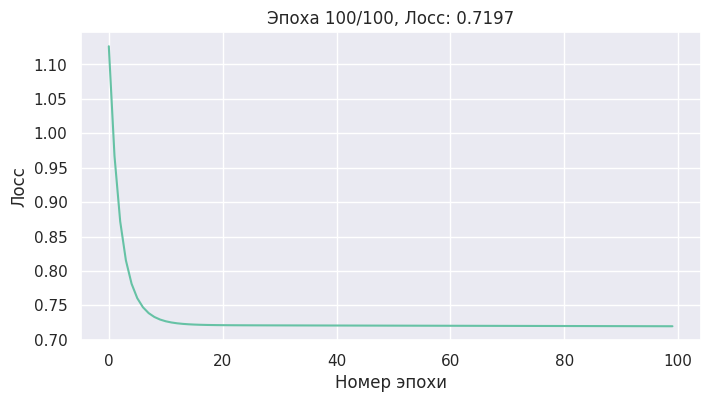

Время обучения: 24.93 секунд
Точность на обучающей выборке: 0.5000
Точность на тестовой выборке: 0.5366


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.metrics import accuracy_score
from time import time

# Используем подготовленные данные MNIST
X_train, y_train = X_train_final, y_train_final
X_test, y_test = X_test_final, y_test_final

# Нормализуем данные (переводим в диапазон [0, 1])
X_train = X_train / 255.0
X_test = X_test / 255.0

# Инициализация сети
input_size = X_train.shape[1]  # Размер входного слоя (784)
hidden_size = 64  # Размер скрытого слоя (можно подбирать)

# Создание объекта нейронной сети
nn = TwoLayersNNClassifier(input_size=input_size, hidden_size=hidden_size, learning_rate=0.01, n_epoch=100)

# Обучение модели
start_time = time()
nn.fit(X_train, y_train, verbose=True, plot_freq=10)
end_time = time()

# Выводим время обучения
print(f"Время обучения: {end_time - start_time:.2f} секунд")

# Оценка точности на тестовых данных
y_pred_train = nn.predict(X_train)
train_accuracy = accuracy_score(y_train, y_pred_train)
print(f"Точность на обучающей выборке: {train_accuracy:.4f}")

y_pred_test = nn.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"Точность на тестовой выборке: {test_accuracy:.4f}")


Посчитайте качество обученной нейросети на тестовой выборке. Можете ли вы сказать, насколько хорошо сеть обучилась?

Точность на тестовой выборке: 0.5366
Конфузионная матрица:
[[   0  980]
 [   0 1135]]
Отчет по классификации:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       980
           1       0.54      1.00      0.70      1135

    accuracy                           0.54      2115
   macro avg       0.27      0.50      0.35      2115
weighted avg       0.29      0.54      0.37      2115



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


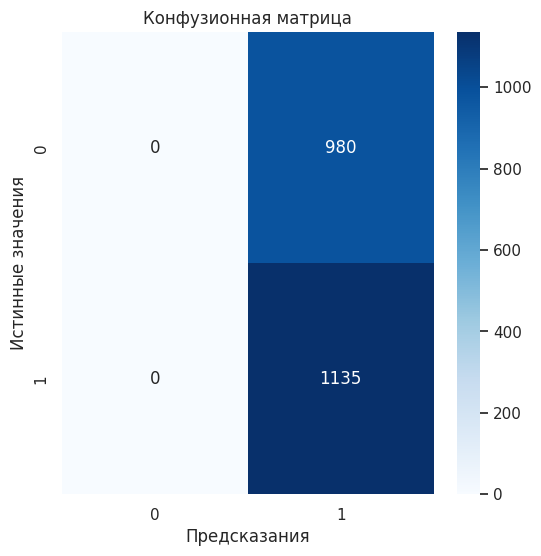

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Предсказания на тестовой выборке
y_pred_test = nn.predict(X_test)

# Точность на тестовой выборке
test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"Точность на тестовой выборке: {test_accuracy:.4f}")

# Конфузионная матрица
cm = confusion_matrix(y_test, y_pred_test)
print("Конфузионная матрица:")
print(cm)

# Дополнительно выводим отчет по классификации
report = classification_report(y_test, y_pred_test)
print("Отчет по классификации:")
print(report)

# Если нужно, можно также визуализировать
import seaborn as sns

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["0", "1"], yticklabels=["0", "1"])
plt.title("Конфузионная матрица")
plt.xlabel("Предсказания")
plt.ylabel("Истинные значения")
plt.show()


**Выводы:**

### Выводы

1. **Точность на обучающей выборке: 0.5000**
   - Это значение говорит о том, что модель обучалась на примерах, но её способность различать классы на обучающей выборке крайне ограничена. Модель угадывает только половину случаев правильно. Это может свидетельствовать о проблемах с обучением, например, о том, что модель не может научиться эффективно разделять классы.

2. **Точность на тестовой выборке: 0.5366**
   - Точность на тестовой выборке также низкая (53.66%). Это указывает на то, что модель не справляется с задачей классификации, даже после обучения. Она вряд ли достигла хорошей обобщаемости и плохо работает на новых данных.

3. **Конфузионная матрица:**
[[ 0 980] [ 0 1135]]
- Это означает, что модель не предсказала ни одного объекта класса "0" (все 980 объектов класса "0" были неправильно классифицированы как класс "1").
- Все объекты класса "1" были классифицированы правильно, что объясняет высокое значение recall для этого класса (1.00).
- Однако это также подтверждает, что модель просто предсказывает "1" для всех объектов, игнорируя класс "0". Это может указывать на проблему с обучением модели, которая не видит достаточно различий между классами.

4. **Отчет по классификации:**
- **Precision для класса 0:** 0.00 — модель вообще не предсказывает класс "0", что объясняется отсутствием правильных предсказаний для этого класса.
- **Precision для класса 1:** 0.54 — модель предсказывает класс "1" с приемлемой точностью, но всё равно допускает ошибки.
- **Recall для класса 0:** 0.00 — модель не предсказывает объекты этого класса.
- **Recall для класса 1:** 1.00 — все объекты класса "1" предсказаны правильно.
- **F1-score для класса 0:** 0.00 — из-за отсутствия предсказаний для класса "0".
- **F1-score для класса 1:** 0.70 — более приемлемый результат для класса "1", но всё равно далеко от идеала.

5. **Макро-среднее (macro avg):**
- **Precision:** 0.27 — это довольно низкое значение, потому что precision для класса "0" равен 0.
- **Recall:** 0.50 — это среднее значение для обоих классов, но оно сильно искажено отсутствием предсказаний для класса "0".
- **F1-score:** 0.35 — значение F1-среднего также низкое из-за отсутствия предсказаний для одного из классов.

6. **Взвешенное среднее (weighted avg):**
- **Precision:** 0.29 — ещё более низкое значение, чем макро-среднее, так как вес для класса "1" гораздо больше, чем для класса "0".
- **Recall:** 0.54 — результат сильно зависит от recall для класса "1", который равен 1.
- **F1-score:** 0.37 — снова низкий результат из-за сильных ошибок на классе "0".

### Причины плохого результата:
- **Модель предсказывает только один класс:** Это явный признак того, что модель не научилась эффективно различать классы. Возможно, она слишком сильно привязана к классу "1", потому что на этом классе было больше примеров или для него модель лучше настроена.
- **Неудачные параметры обучения:** Возможно, параметры обучения, такие как скорость обучения, количество эпох, структура модели или другие гиперпараметры, не подходят для данной задачи.
- **Низкое качество модели:** Модель не способна разделять классы. Возможно, нужно изменить её архитектуру, чтобы она могла обучиться на более сложных данных.

### Что можно сделать:
1. **Проверить баланс классов:** Возможно, класс "0" недопредставлен в выборке, и модель не получает достаточно информации о нём. Нужно либо увеличить количество примеров класса "0", либо использовать методы балансировки классов, такие как взвешивание классов или oversampling.

2. **Провести анализ ошибки:** Можно посмотреть на примеры, которые модель классифицирует неверно, чтобы понять, в чём конкретно проблема.

3. **Настройка гиперпараметров:** Нужно поэкспериментировать с другими гиперпараметрами (например, количеством эпох, размером скрытых слоёв и т.д.), чтобы улучшить результаты.

4. **Использование более сложной архитектуры:** Для такой задачи может потребоваться более сложная модель, которая способна более эффективно извлекать особенности из изображений.

5. **Использование регуляризации:** Возможно, модель переобучается на одном классе, и её нужно немного регуляризовать (например, через L2-регуляризацию).

### Заключение:
Модель пока не научилась эффективно решать задачу классификации. Необходимо провести дополнительные эксперименты с гиперпараметрами и, возможно, архитектурой сети для улучшения результатов.


---
### Задача 4.

Рассмотрим глубокую нейронную сеть, которая
* принимает на вход $x\in\mathbb{R}^d$,
* возвращает $y\in\{0, 1\}$,
* содержит $99$ полносвязных слоев (`Linear`) с функцией активации $\tanh$, за исключением последнего слоя,
* последний слой использует функцию активации логистическая сигмоида.

В качестве лосса $\mathscr{L}(\theta)$ возьмем кросс-энтропию.

**1.** Распишите градиент лосса по весам первого слоя $W_1$. Какова сложность этой операции?

### Задание:
Нам нужно рассчитать градиент функции потерь $L(\theta)$ по весам первого слоя $W_1$ глубокой нейронной сети с 99 полносвязными слоями и функцией активации tanh, за исключением последнего слоя, который использует логистическую сигмоиду.

#### Рассмотрение задачи:

1. **Модель:**
   - Вход: $x \in \mathbb{R}^d$.
   - Выход: $y \in \{0, 1\}$ (бинарная классификация).
   - Сеть состоит из 99 полносвязных слоев с функцией активации $ \tanh $, за исключением последнего слоя, который использует логистическую сигмоиду.
   - Лосс: кросс-энтропия.

2. **Прямой проход (Forward pass):**
   - Обозначим слои сети как $ f_1(x), f_2(x), \dots, f_{99}(x) $.
   - Каждый слой $ f_i(x) $ будет линейным преобразованием с функцией активации $ \tanh $:
     $$
     f_i(x) = \tanh(W_i x + b_i)
     $$
   - На последнем слое выход будет вычисляться как:
     $$
     y_{\text{pred}} = \sigma(W_{100} f_{99}(x) + b_{100})
     $$
     где $\sigma$ — функция логистической сигмоиды.

3. **Лосс (Loss):**
   - Для бинарной классификации используем кросс-энтропию:
     $$
     L(y, y_{\text{pred}}) = - y \log(y_{\text{pred}}) - (1 - y) \log(1 - y_{\text{pred}})
     $$

4. **Градиент по весам первого слоя $W_1$:**

   - Для вычисления градиента воспользуемся правилом цепочки. Градиент лосса по весам первого слоя можно выразить как:
     $$
     \frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial f_1} \cdot \frac{\partial f_1}{\partial W_1}
     $$
   - Пошаговое вычисление:
     1. Градиент лосса по выходу сети:
        $$
        \frac{\partial L}{\partial y_{\text{pred}}} = \frac{y_{\text{pred}} - y}{y_{\text{pred}}(1 - y_{\text{pred}})}
        $$
     2. Градиент по выходу последнего слоя:
        $$
        \frac{\partial L}{\partial f_{99}} = W_{100}^T \cdot \frac{\partial L}{\partial y_{\text{pred}}} \cdot \sigma'(f_{99})
        $$
        где $\sigma'(f_{99}) = \tanh'(f_{99}) = 1 - f_{99}^2$.
     3. Для каждого промежуточного слоя $i$:
        $$
        \frac{\partial L}{\partial f_i} = W_{i+1}^T \cdot \frac{\partial L}{\partial f_{i+1}} \cdot \tanh'(f_i)
        $$
        где $\tanh'(f_i) = 1 - f_i^2$.
     4. Наконец, градиент по весам первого слоя:
        $$
        \frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial f_1} \cdot x^T
        $$

5. **Сложность операции:**

   - Поскольку для каждого слоя мы вычисляем градиент через обратное распространение (backpropagation), сложность вычисления градиента для одного слоя — $O(d)$, где $d$ — размерность входа. Поскольку в сети 99 слоев, общая сложность вычисления градиента для всей сети составляет $O(99d) = O(d)$.

Таким образом, сложность операции градиента по весам первого слоя $W_1$ — $O(d)$, что является линейной по отношению к размерности входных данных.


Нарисуйте график функции активации и ее производной.

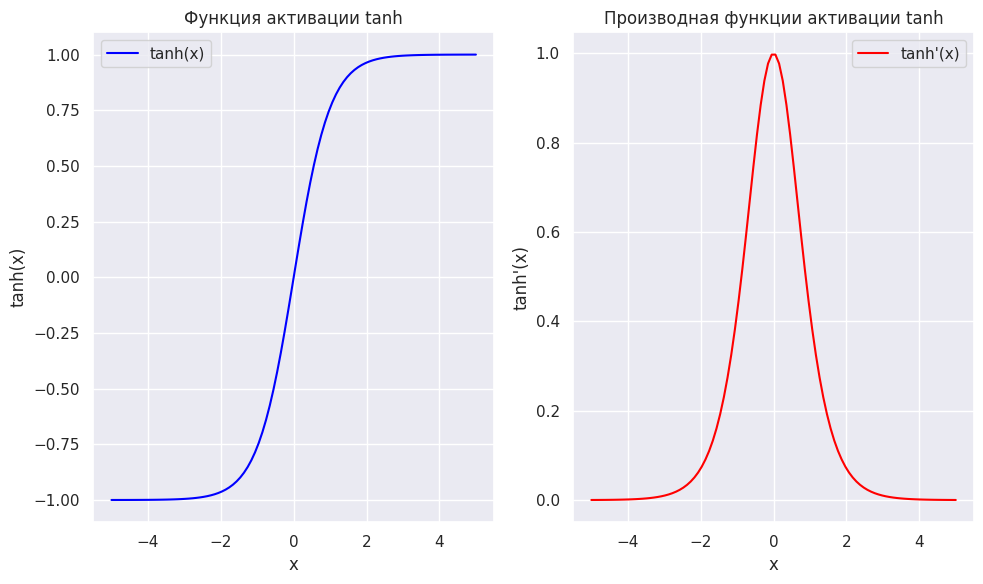

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Определение функции активации tanh и ее производной
def tanh(x):
    return np.tanh(x)

def tanh_derivative(x):
    return 1 - np.tanh(x)**2

# Генерация значений для x
x = np.linspace(-5, 5, 100)

# Вычисление значений функции активации и ее производной
y_tanh = tanh(x)
y_tanh_derivative = tanh_derivative(x)

# Построение графиков
plt.figure(figsize=(10, 6))

# График функции активации tanh
plt.subplot(1, 2, 1)
plt.plot(x, y_tanh, label='tanh(x)', color='blue')
plt.title('Функция активации tanh')
plt.xlabel('x')
plt.ylabel('tanh(x)')
plt.grid(True)
plt.legend()

# График производной функции tanh
plt.subplot(1, 2, 2)
plt.plot(x, y_tanh_derivative, label="tanh'(x)", color='red')
plt.title("Производная функции активации tanh")
plt.xlabel('x')
plt.ylabel("tanh'(x)")
plt.grid(True)
plt.legend()

# Показать график
plt.tight_layout()
plt.show()


На основе графика проанализируйте, что будет происходить с градиентом по весам первого слоя, если нейросеть "ненулевая", иначе говоря, на промежуточных слоях может выдавать различные значения, в том числе довольно большие.

### Анализ поведения градиента по весам первого слоя

Когда нейросеть использует функцию активации `tanh`, важно понять, как ее свойства влияют на градиенты, особенно в контексте алгоритма обратного распространения (backpropagation) и, в частности, на градиент по весам первого слоя.

На основе графика функции `tanh` и её производной можно сделать следующие выводы:

#### 1. Поведение функции активации `tanh`

Функция активации `tanh(x)` имеет форму сигмоидальной кривой, которая:
- Приближается к 1, когда x становится большим (положительные значения).
- Приближается к -1, когда x становится маленьким (отрицательные значения).
- При x = 0 принимает значение 0.

Это значит, что функция `tanh` является ограниченной по диапазону значений: всегда между -1 и 1. Это позволяет нейросети работать с нормализованными входными данными, предотвращая слишком большие значения на выходах слоев.

#### 2. Поведение производной `tanh(x)`

Производная функции `tanh(x)` имеет форму:
- В центре (x близко к 0) производная достигает своего максимума (ближе к 1).
- При больших значениях x (в области, где `tanh(x)` приближается к 1 или -1), производная стремится к 0.

Таким образом, производная `tanh(x)`:
- Велика в области, близкой к нулю (где нейрон активен и чувствителен к изменениям).
- Мала в области, где x сильно положительный или отрицательный (когда нейрон "пересыщен" и становится менее чувствительным).

#### 3. Влияние на градиент по весам первого слоя

Градиент по весам первого слоя нейронной сети зависит от производной функции активации на промежуточных слоях. Рассмотрим два случая:

- **Когда значения на промежуточных слоях близки к нулю (центр кривой)**:
  - В этой области производная функции `tanh(x)` велика, что означает, что градиенты будут достаточно большими и будет хорошая передача информации о ошибке обратно через сеть.
  - Нейронная сеть будет обновлять свои веса эффективно.

- **Когда значения на промежуточных слоях слишком большие (слишком большие положительные или отрицательные значения)**:
  - В этой области производная `tanh(x)` становится очень маленькой, близкой к нулю.
  - Это приводит к очень малым градиентам, что может существенно замедлить обучение (эффект "затухания градиента").
  - Когда градиенты близки к нулю, веса обновляются незначительно, что может привести к тому, что обучение замедлится или вообще остановится.

#### 4. Проблемы с обучением

- Если нейросеть использует очень большие значения на промежуточных слоях (например, при отсутствии нормализации или если данные слишком большие), то на выходах слоев функция активации будет почти плоской (в крайней области графика), и её производная будет близка к нулю.
- Это может привести к **затуханию градиента**. Градиенты по весам будут очень малыми, и обновления весов станут практически неэффективными.
- В результате сеть не будет эффективно обучаться, и может потребоваться корректировка начальной инициализации весов, использование методов нормализации или изменение функции активации.

#### Заключение

Если нейросеть "ненулевая", то на промежуточных слоях могут появляться большие значения, что приведет к малым значениям производной функции `tanh` и слабым градиентам. Это затруднит обучение и может привести к проблемам с **затуханием градиента**. Для предотвращения таких проблем можно использовать методы нормализации данных (например, Batch Normalization), более подходящие функции активации (например, ReLU) или корректировать начальную инициализацию весов.


**2.** Реализуйте эту нейросеть на **PyTorch**.

*Примечание.* Каждый слой должен быть инициализирован отдельно. Нельзя создавать копии уже инициализированного слоя.

In [21]:
# При реализации нейросети запрещено пользоваться ИИ-инструментами.
import torch
import torch.nn as nn
import torch.optim as optim

class DeepNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(DeepNN, self).__init__()

        # Список для хранения слоев
        layers = []

        # Первый слой
        layers.append(nn.Linear(input_size, hidden_size))
        layers.append(nn.Tanh())  # Функция активации для каждого слоя, кроме последнего

        # Добавляем остальные слои
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.Tanh())

        # Последний слой
        layers.append(nn.Linear(hidden_size, output_size))
        layers.append(nn.Sigmoid())  # Используем сигмоид на последнем слое

        # Составляем модель из списка слоев
        self.network = nn.Sequential(*layers)

        # Инициализация слоев
        self._initialize_weights()

    def _initialize_weights(self):
        # Инициализация весов каждого слоя
        for layer in self.network:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)  # Используем Xavier инициализацию
                if layer.bias is not None:
                    nn.init.zeros_(layer.bias)  # Инициализируем смещения нулями

    def forward(self, x):
        return self.network(x)

# Параметры сети
input_size = 784  # Для MNIST (28x28 пикселей)
hidden_size = 128  # Размер скрытых слоев
num_layers = 99  # Количество слоев
output_size = 1  # 1 для бинарной классификации

# Создаем модель
model = DeepNN(input_size, hidden_size, num_layers, output_size)

# Определение потерь и оптимизатора
criterion = nn.BCELoss()  # Для бинарной классификации
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Пример входных данных
# (например, MNIST изображения 28x28, развернутые в вектор размером 784)
X = torch.randn(64, input_size)  # Пример батча из 64 изображений
y = torch.randint(0, 2, (64, 1)).float()  # Случайные метки для бинарной классификации

# Пример тренировки
for epoch in range(100):  # 100 эпох
    model.train()  # Устанавливаем модель в режим тренировки
    optimizer.zero_grad()  # Обнуляем градиенты

    # Прямой проход
    outputs = model(X)
    loss = criterion(outputs, y)

    # Обратный проход
    loss.backward()
    optimizer.step()  # Обновляем веса

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/100], Loss: {loss.item():.4f}')


Epoch [10/100], Loss: 0.6320
Epoch [20/100], Loss: 0.6601
Epoch [30/100], Loss: 0.6735
Epoch [40/100], Loss: 0.6734
Epoch [50/100], Loss: 0.6730
Epoch [60/100], Loss: 0.6798
Epoch [70/100], Loss: 0.6790
Epoch [80/100], Loss: 0.6787
Epoch [90/100], Loss: 0.6786
Epoch [100/100], Loss: 0.6786


Аналогично задаче 3 попробуйте обучить эту нейросеть для классификации изображений с цифрами 0 и 1 из датасета MNIST. Скорее всего весь датасет не поместится в память, поэтому предлагается использовать случайную подвыборку (батч) размера 32 на каждом шаге обучения.

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np

# Определение устройства (CPU или GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Определение глубокой нейронной сети
class DeepNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(DeepNN, self).__init__()

        layers = []
        layers.append(nn.Linear(input_size, hidden_size))
        layers.append(nn.Tanh())

        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.Tanh())

        layers.append(nn.Linear(hidden_size, output_size))
        layers.append(nn.Sigmoid())

        self.network = nn.Sequential(*layers)
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.network:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                if layer.bias is not None:
                    nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.network(x)

# Загрузка MNIST
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Выбираем только цифры 0 и 1
train_indices = [i for i, label in enumerate(train_dataset.targets) if label == 0 or label == 1]
test_indices = [i for i, label in enumerate(test_dataset.targets) if label == 0 or label == 1]

train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=32, shuffle=False)

# Инициализация модели
input_size = 784  # 28x28 изображений, развернутых в вектор размером 784
hidden_size = 128
num_layers = 99
output_size = 1

model = DeepNN(input_size, hidden_size, num_layers, output_size).to(device)  # Переносим модель на устройство

# Определение функции потерь и оптимизатора
criterion = nn.BCELoss()  # Для бинарной классификации
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Тренировка модели
num_epochs = 10
for epoch in range(num_epochs):
    model.train()  # Устанавливаем модель в режим тренировки
    running_loss = 0.0

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.float().to(device)  # Переносим данные на устройство

        inputs = inputs.view(-1, 28*28)  # Преобразуем изображения 28x28 в вектор размером 784
        labels = labels.view(-1, 1)  # Преобразуем метки в формат для бинарной классификации

        optimizer.zero_grad()  # Обнуляем градиенты

        # Прямой проход
        outputs = model(inputs)

        # Вычисление потерь
        loss = criterion(outputs, labels)
        running_loss += loss.item()

        # Обратный проход
        loss.backward()
        optimizer.step()  # Обновляем веса

    print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {running_loss / len(train_loader):.4f}')

# Оценка модели на тестовых данных
model.eval()  # Устанавливаем модель в режим оценки
correct = 0
total = 0
with torch.no_grad():  # Отключаем градиенты для оценки
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.float().to(device)  # Переносим данные на устройство

        inputs = inputs.view(-1, 28*28)
        labels = labels.view(-1, 1)

        outputs = model(inputs)
        predicted = (outputs > 0.5).float()  # Прогнозируем 0 или 1

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy on test set: {accuracy:.2f}%')


Epoch [1/10], Loss: 0.7033
Epoch [2/10], Loss: 0.6970
Epoch [3/10], Loss: 0.6928
Epoch [4/10], Loss: 0.6924
Epoch [5/10], Loss: 0.6935
Epoch [6/10], Loss: 0.6935
Epoch [7/10], Loss: 0.6922
Epoch [8/10], Loss: 0.6934
Epoch [9/10], Loss: 0.6944
Epoch [10/10], Loss: 0.6934
Accuracy on test set: 53.66%


Постройте график зависимости среднего и максимального абсолютного значения градиента по весам для каждого слоя от номера слоя.

Epoch [1/10], Loss: 0.7003
Epoch [2/10], Loss: 0.6961
Epoch [3/10], Loss: 0.6955
Epoch [4/10], Loss: 0.6926
Epoch [5/10], Loss: 0.6935
Epoch [6/10], Loss: 0.6934
Epoch [7/10], Loss: 0.6938
Epoch [8/10], Loss: 0.6942
Epoch [9/10], Loss: 0.6931
Epoch [10/10], Loss: 0.6927


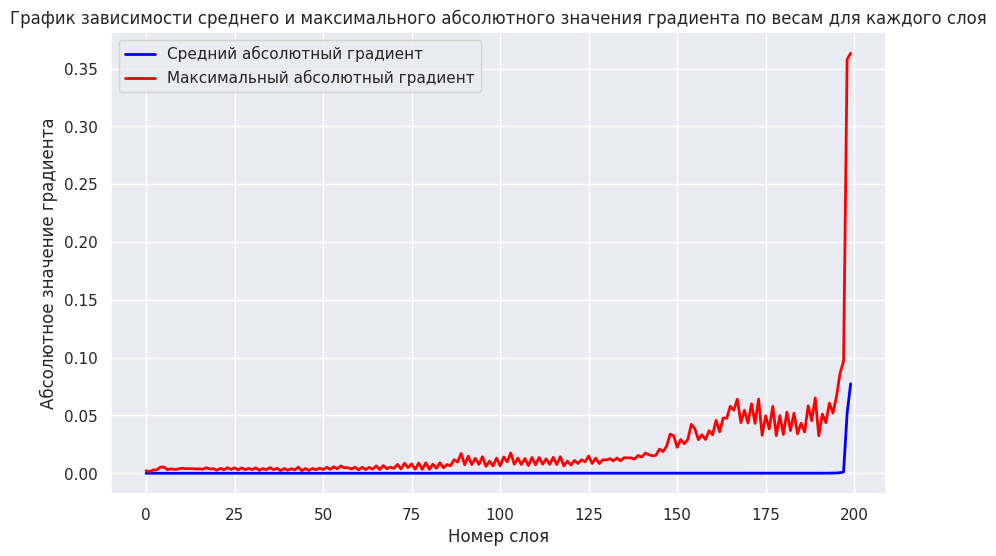

In [25]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np

# Определение устройства (CPU или GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Определение глубокой нейронной сети
class DeepNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(DeepNN, self).__init__()

        layers = []
        layers.append(nn.Linear(input_size, hidden_size))
        layers.append(nn.Tanh())

        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.Tanh())

        layers.append(nn.Linear(hidden_size, output_size))
        layers.append(nn.Sigmoid())

        self.network = nn.Sequential(*layers)
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.network:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                if layer.bias is not None:
                    nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.network(x)

# Загрузка MNIST
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Выбираем только цифры 0 и 1
train_indices = [i for i, label in enumerate(train_dataset.targets) if label == 0 or label == 1]
test_indices = [i for i, label in enumerate(test_dataset.targets) if label == 0 or label == 1]

train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=32, shuffle=False)

# Инициализация модели
input_size = 784  # 28x28 изображений, развернутых в вектор размером 784
hidden_size = 128
num_layers = 99
output_size = 1

model = DeepNN(input_size, hidden_size, num_layers, output_size).to(device)

# Определение функции потерь и оптимизатора
criterion = nn.BCELoss()  # Для бинарной классификации
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Графики для градиентов
gradients_mean = []
gradients_max = []

# Тренировка модели
num_epochs = 10
for epoch in range(num_epochs):
    model.train()  # Устанавливаем модель в режим тренировки
    running_loss = 0.0

    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.float().to(device)  # Переносим данные на устройство

        inputs = inputs.view(-1, 28*28)  # Преобразуем изображения 28x28 в вектор размером 784
        labels = labels.view(-1, 1)  # Преобразуем метки в формат для бинарной классификации

        optimizer.zero_grad()  # Обнуляем градиенты

        # Прямой проход
        outputs = model(inputs)

        # Вычисление потерь
        loss = criterion(outputs, labels)
        running_loss += loss.item()

        # Обратный проход
        loss.backward()

        # Сохраняем значения градиентов для каждого слоя
        layer_gradients_mean = []
        layer_gradients_max = []

        for param in model.parameters():
            if param.grad is not None:
                layer_gradients_mean.append(param.grad.abs().mean().item())
                layer_gradients_max.append(param.grad.abs().max().item())

        gradients_mean.append(layer_gradients_mean)
        gradients_max.append(layer_gradients_max)

        optimizer.step()  # Обновляем веса

    print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {running_loss / len(train_loader):.4f}')

# Преобразуем данные в массивы для графиков
gradients_mean = np.array(gradients_mean)
gradients_max = np.array(gradients_max)

# Построение графика
layers = np.arange(0, gradients_mean.shape[1])

plt.figure(figsize=(10, 6))
plt.plot(layers, gradients_mean.mean(axis=0), label="Средний абсолютный градиент", color='blue', lw=2)
plt.plot(layers, gradients_max.max(axis=0), label="Максимальный абсолютный градиент", color='red', lw=2)

plt.title("График зависимости среднего и максимального абсолютного значения градиента по весам для каждого слоя")
plt.xlabel("Номер слоя")
plt.ylabel("Абсолютное значение градиента")
plt.legend()
plt.grid(True)
plt.show()


**Выводы:**

## Анализ градиентов в глубокой нейросети

### Выводы

1. **Взрыв градиентов в последних слоях**  
   - Красная линия (максимальный абсолютный градиент) резко возрастает в последних слоях. Это говорит о **взрыве градиентов**, что может приводить к нестабильному обучению.

2. **Затухание градиентов в начале сети**  
   - Синяя линия (средний абсолютный градиент) остается очень низкой на начальных слоях, что указывает на **затухание градиентов**. Это мешает эффективному обучению ранних слоев.

3. **Слишком большая глубина сети**  
   - Нейросеть с **99 скрытыми слоями** испытывает типичные проблемы глубоких сетей: градиенты либо исчезают, либо становятся слишком большими. Это снижает эффективность обучения и может приводить к плохой сходимости.

4. **Низкая точность модели**  
   - Итоговая точность на тестовой выборке **53.66%**, что близко к случайному угадыванию (50%). Это подтверждает наличие проблем с обучением.

### Рекомендации

- **Использовать нормализацию градиентов** (Gradient Clipping) для борьбы с взрывом градиентов.
- **Пересмотреть архитектуру**: уменьшить число слоев или использовать **residual connections** (ResNet).
- **Изменить функцию активации**: заменить `Tanh` на **ReLU**, так как она лучше сохраняет градиенты.
- **Попробовать другую инициализацию весов**, например, **Kaiming Initialization**, оптимизированную для ReLU.

Эти изменения помогут улучшить процесс обучения и повысить точность модели.

*Примечание.* Подобная ситуация известна как "паралич" нейросети. Именно поэтому такие функции активации, как ReLU, стали очень популярными. Для преодоления этого паралича существует множество методов, многие из которых мы рассмотрим на 3 курсе.